In [12]:
# capstone project -- function 3 (3D)

import os
import numpy as np
import warnings
import matplotlib.pyplot as plt
import pandas as pd

from bayes_tools import (
    normalize, initial_bounds, generate_next_point, ucb_acquisition, pi_acquisition,
    fit_gp, get_length_scales, loo_predictions,
    init_history, load_history, propose_and_log, record_observation,
)
from viz_tools import (
    plot_nd_slices, plot_loo_calibration,
    plot_convergence, plot_acquisition_decay, plot_uncertainty_shrinkage, plot_step_distance,
)


# Function 3

Function 3 is 3D, so `plot_2d_bo`'s contour panels no longer apply directly (that tool covers exactly 2 input dimensions). This notebook uses the higher-dimensional tooling instead:

- **`plot_nd_slices`** -- the direct generalisation of `plot_1d_bo`/`plot_2d_bo`: a 1D slice through each dimension, holding the other two fixed at the current best point.
- **`get_length_scales`** -- which of the 3 dimensions the GP thinks actually matter, useful once D gets larger than this and you don't want a slice panel per dimension.
- **`loo_predictions` / `plot_loo_calibration`** -- a numerical check that the surrogate model itself is trustworthy, which matters more here than in 1D/2D since you can no longer just look at the fitted surface and eyeball whether it seems reasonable.
- **History tracking** (`init_history` / `propose_and_log` / `record_observation`) plus the iteration-level diagnostics (`plot_convergence`, `plot_acquisition_decay`, `plot_uncertainty_shrinkage`, `plot_step_distance`) -- these don't care about input dimension at all, so they carry over from the 2D functions unchanged.


## Load the initial batch

In [19]:
X = np.load("initial_data/function_3/initial_inputs.npy")
y = np.load("initial_data/function_3/initial_outputs.npy")


In [20]:
# Get some info about what we loaded

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X range per dimension:")
print("  min:", X.min(axis=0))
print("  max:", X.max(axis=0))
print("y range:", y.min(), "to", y.max())

assert X.shape[1] == 3, f"Expected a 3D problem, got {X.shape[1]}D input -- check the loaded file."

bounds = initial_bounds(X, pad_fraction=1.0)
print("\nBounds:\n", bounds)

print(y)


X shape: (15, 3)
y shape: (15,)
X range per dimension:
  min: [0.04680895 0.21991724 0.06608864]
  max: [0.96599485 0.94135983 0.99088187]
y range: -0.3989255131463011 to -0.034835313350078584

Bounds:
 [[-0.87237695  1.88518075]
 [-0.50152535  1.66280242]
 [-0.85870458  1.91567509]]
[-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837]


## Sensitivity check: which dimensions actually matter

Fit a GP directly on the initial batch and look at the per-dimension length-scales (ARD). A short length-scale means the GP thinks the function varies quickly along that axis; one sitting near the upper `length_scale_bounds` means that axis looks close to irrelevant. Useful to know before staring at 3 slice panels -- and essential once a future function has 6-8 dimensions and slicing all of them isn't practical.

In [4]:
gp_initial = fit_gp(X, y, bounds, n_restarts_optimizer=20, random_state=0)
length_scales = get_length_scales(gp_initial)

for dim, ls in sorted(enumerate(length_scales), key=lambda t: t[1]):
    tag = "(most sensitive)" if ls == length_scales.min() else ("(least sensitive)" if ls == length_scales.max() else "")
    print(f"x{dim}: length_scale = {ls:.3f} {tag}")


x2: length_scale = 0.033 (most sensitive)
x0: length_scale = 10.000 (least sensitive)
x1: length_scale = 10.000 (least sensitive)


/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Propose the next point

Using `pi` (Probability of Improvement) here, matching the acquisition assigned to function 3 in the generalised sweep over all functions.

In [10]:


x_next, gp = generate_next_point(
    X, y, bounds,
    acquisition="pi", xi=0.01, maximize=True,
    n_restarts=25, random_state=0,
    gp_kwargs={"n_restarts_optimizer": 20, "length_scale_bounds": (1e-2, 100.0)},
)

print(f"\n--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 4))
print(gp.kernel_)

mu, sigma = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)
print(f"GP predicted mean: {mu[0]:.4f}, predicted std: {sigma[0]:.4f}")



--- Next point to evaluate (bounds shape (3, 2)) ---
x_next: [1.0261 0.3402 0.0274]
1.45**2 * Matern(length_scale=[100, 100, 0.0335], nu=2.5) + WhiteKernel(noise_level=0.0143)
GP predicted mean: -0.0409, predicted std: 0.0555


/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Visualise the GP and acquisition function via 1D slices

Each panel holds the other two dimensions fixed at the current best observed point and sweeps one dimension -- the same GP-mean-plus-CI and acquisition-function view as `plot_1d_bo`, just repeated once per input dimension. Black dots are observations that fall close to this slice in the *other* two dimensions; the dotted line is the fixed centre, the dashed red line is the proposed `x_next`.

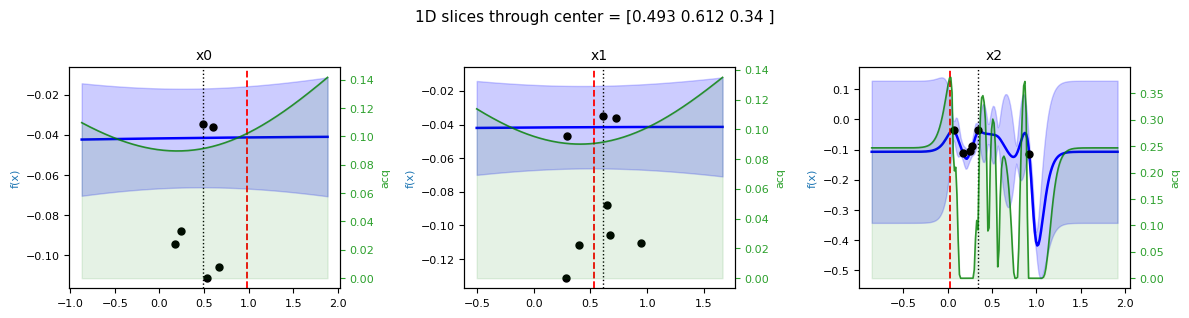

In [6]:
fig = plot_nd_slices(
    X, y, bounds, gp,
    acquisition_fn=pi_acquisition,
    x_next=x_next,
    acq_kwargs={"y_best": y.max(), "xi": 0.01, "maximize": True},
)
plt.show()


## Sanity-check the surrogate model: leave-one-out calibration

Refits the GP once per observation, leaving it out each time, and predicts it from the rest. If the points track the diagonal and the error bars mostly cover it, the GP is a trustworthy stand-in for the true function -- worth checking explicitly here since you can no longer just look at the fitted surface directly the way you can in 1D/2D.

/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/

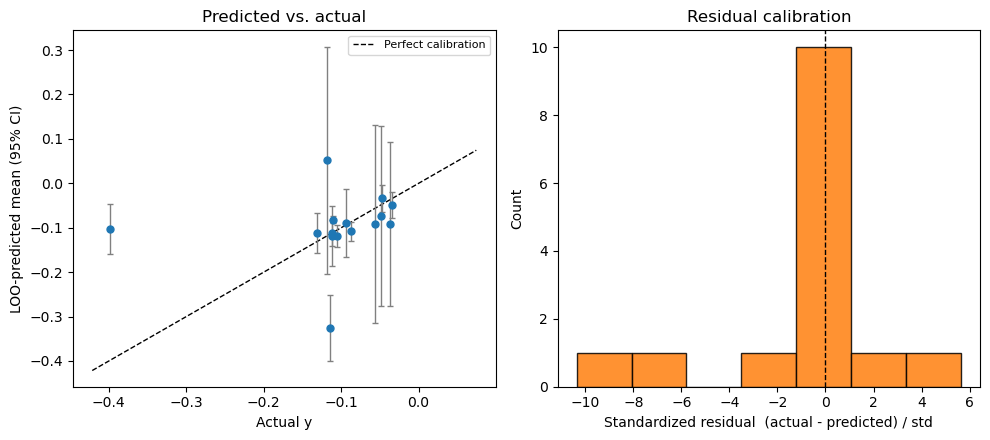

In [7]:
pred_mean, pred_std = loo_predictions(X, y, bounds, gp_kwargs={"n_restarts_optimizer": 20})
fig = plot_loo_calibration(y, pred_mean, pred_std)
plt.show()


## Iteration history tracking across weeks

Since new `y` values arrive externally (submit `x_next`, find out the result later), this persists a small log per function on disk. Each week:

1. If it's the very first time for this function, seed the log with the initial batch.
2. If there's a pending proposal from last time, record its result once known.
3. Propose the next point (this also logs the acquisition value, GP hyperparameters, and domain-wide uncertainty at proposal time, for the diagnostics below).


In [8]:
history_path = "initial_data/function_3/history.npz"

# Run once per function, ever -- seeds the log with the initial batch.
if not os.path.exists(history_path):
    init_history(X, y, history_path)

history = load_history(history_path)
pending = np.isnan(history["y"])

if pending.any():
    print(f"Pending proposal awaiting a result: {history['X'][pending][0]}")
    print("Fill this in below once you know the true y, then re-run this cell.")
    # record_observation(history_path, y_observed=<value you got back>, x_observed=history['X'][pending][0])
else:
    x_next, gp = propose_and_log(
        history_path, bounds,
        acquisition="pi", xi=0.01, maximize=True,
        n_restarts=25, random_state=0,
        gp_kwargs={"n_restarts_optimizer": 20},
    )
    print("Next point to evaluate:", np.round(x_next, 4))


Next point to evaluate: [0.9852 0.5343 0.0283]


/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Diagnostics once a few iterations have completed

These are dimension-agnostic -- they operate on `y`, `iteration`, and distances in `X`, not on the shape of the input space -- so they carry over unchanged from the 2D functions. (`plot_sample_trajectory` and `plot_bo_diagnostics` are the two exceptions: both hard-code a 2D scatter panel, so they're skipped here.)

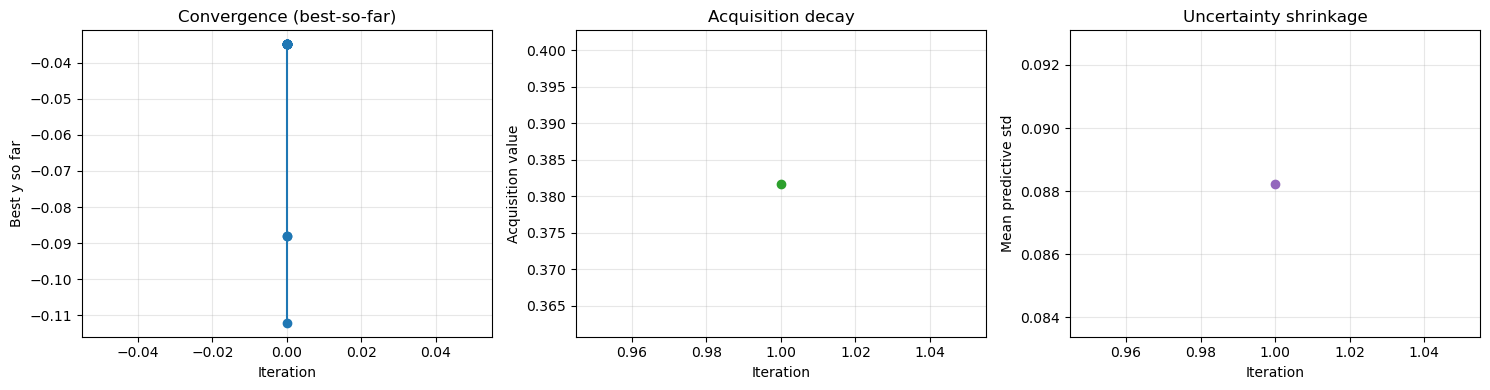

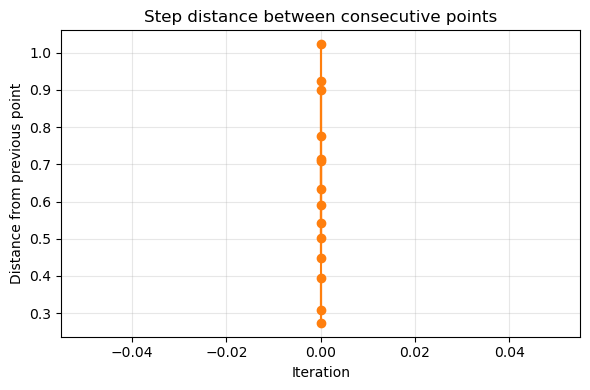

In [9]:
history = load_history(history_path)
n_completed = int((~np.isnan(history["y"])).sum())

if n_completed >= 3:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    obs = ~np.isnan(history["y"])
    it, yv = history["iteration"][obs], history["y"][obs]
    order = np.argsort(it)
    axes[0].plot(it[order], np.maximum.accumulate(yv[order]), marker="o", color="tab:blue")
    axes[0].set_title("Convergence (best-so-far)")
    axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Best y so far"); axes[0].grid(alpha=0.3)

    has_acq = ~np.isnan(history["acq_value"])
    it_a, acq = history["iteration"][has_acq], history["acq_value"][has_acq]
    o = np.argsort(it_a)
    axes[1].plot(it_a[o], acq[o], marker="o", color="tab:green")
    axes[1].set_title("Acquisition decay")
    axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Acquisition value"); axes[1].grid(alpha=0.3)

    has_std = ~np.isnan(history["domain_mean_std"])
    it_s, std = history["iteration"][has_std], history["domain_mean_std"][has_std]
    o = np.argsort(it_s)
    axes[2].plot(it_s[o], std[o], marker="o", color="tab:purple")
    axes[2].set_title("Uncertainty shrinkage")
    axes[2].set_xlabel("Iteration"); axes[2].set_ylabel("Mean predictive std"); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    fig2 = plot_step_distance(history)
    plt.show()
else:
    print(f"Only {n_completed} completed iteration(s) so far -- need at least 3 for the "
          "trend plots above to be meaningful. Re-run once more results have come in.")
